IMPORT LIBRARIES

In [1]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

LOAD DATASET

In [2]:
file_path = "/content/data đồ án.xlsm"

df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label", "Rate"]].dropna()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape: (31460, 3)

Label distribution:
Label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


TEXT PREPROCESSING

In [3]:
def preprocess(text):
    text = str(text).lower()

    # Chuẩn hóa một số từ viết tắt phổ biến trong comment tiếng Việt
    replacements = {
        " ko ": " không ",
        " k ": " không ",
        " kh ": " không ",
        " hok ": " không ",
        " kg ": " không ",
        " dc ": " được ",
        " đc ": " được ",
        " sp ": " sản phẩm ",
        " shop ": " shop ",
        " ok ": " tốt ",
        " oke ": " tốt ",
    }

    text = " " + text + " "
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Bỏ ký tự đặc biệt, giữ chữ tiếng Việt
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)

    # Bỏ số
    text = re.sub(r"\d+", " ", text)

    # Giảm ký tự lặp quá nhiều: đẹpppp -> đẹpp
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Comment"].apply(preprocess)

print(df[["Comment", "clean_text", "Label"]].head())

                       Comment                  clean_text Label
0               Áo bao đẹp ạ!!                áo bao đẹp ạ   POS
1                  Tuyệt vời !                   tuyệt vời   POS
2   2day ao khong giong trong.    day ao khong giong trong   NEG
3  Mùi thơm,bôi lên da mềm da.  mùi thơm bôi lên da mềm da   POS
4            Vải đẹp, dày dặn.             vải đẹp dày dặn   POS


TRAIN / TEST SPLIT

In [4]:
X = df["clean_text"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 25168
Test size: 6292

Train label distribution:
Label
POS    16074
NEG     5335
NEU     3759
Name: count, dtype: int64

Test label distribution:
Label
POS    4019
NEG    1334
NEU     939
Name: count, dtype: int64


FEATURE ENGINEERING

In [5]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    max_features=30000,
    min_df=2,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    min_df=2,
    sublinear_tf=True
)

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])

print("Feature engineering setup completed.")

Feature engineering setup completed.


BUILD NAIVE BAYES MODEL

In [6]:
model = ComplementNB(alpha=0.05, norm=True)

pipeline = Pipeline([
    ("features", features),
    ("model", model)
])

print("Pipeline created successfully.")

Pipeline created successfully.


GRID SEARCH

In [7]:
param_grid = {
    "model__alpha": [0.01, 0.05, 0.1, 0.5, 1.0],
    "model__norm": [True, False]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Grid Search completed.")
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Grid Search completed.
Best Parameters: {'model__alpha': 0.5, 'model__norm': True}


EVALUATION

In [8]:
y_pred = best_model.predict(X_test)

print("\n==== MODEL NAIVE BAYES ====")
print("Best Parameters:", grid.best_params_)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


==== MODEL NAIVE BAYES ====
Best Parameters: {'model__alpha': 0.5, 'model__norm': True}
Accuracy: 0.7754291163382072

Confusion Matrix:
[[ 970   99  265]
 [ 340  156  443]
 [ 178   88 3753]]

Classification Report:
              precision    recall  f1-score   support

         NEG     0.6519    0.7271    0.6875      1334
         NEU     0.4548    0.1661    0.2434       939
         POS     0.8413    0.9338    0.8851      4019

    accuracy                         0.7754      6292
   macro avg     0.6493    0.6090    0.6053      6292
weighted avg     0.7435    0.7754    0.7475      6292



Calculate Params, Model Size, Inference Time, FPS

In [9]:
import time
import os
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. PERFORMANCE METRICS

main_metric = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")
recall    = recall_score(y_test, y_pred, average="macro")
f1        = f1_score(y_test, y_pred, average="macro")

# 2. PARAMETERS / PARAMS

nb_model     = best_model.named_steps["model"]
total_params = nb_model.feature_log_prob_.size + nb_model.class_log_prior_.size
params_million = total_params / 1_000_000

# 3. MODEL SIZE

model_path = "naive_bayes_emotion_model.pkl"
joblib.dump(best_model, model_path)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

# 4. FPS / INFERENCE TIME

X_test_list = list(X_test)

start_time = time.time()
_ = best_model.predict(X_test_list)
end_time   = time.time()

total_time        = end_time - start_time
num_samples       = len(X_test_list)
fps               = num_samples / total_time
inference_time_ms = (total_time / num_samples) * 1000

# 5. ESTIMATED FLOPs

num_features     = best_model.named_steps["features"].transform(X_train[:1]).shape[1]
num_classes      = len(nb_model.classes_)
flops_per_sample = 2 * num_features * num_classes
flops_g          = flops_per_sample / 1_000_000_000

# 6. PRINT VALUES

print("Main Metric / Accuracy:", round(main_metric, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("Params:", f"{params_million:.4f} M")
print("FPS:", f"{fps:.2f}")

print("Parameters:", f"{params_million:.4f} M")
print("Model Size:", f"{model_size_mb:.2f} MB")
print("FLOPs:", f"{flops_g:.6f} G")
print("FPS / Inference Time:", f"{fps:.2f} FPS / {inference_time_ms:.4f} ms")

Main Metric / Accuracy: 0.7754
Precision: 0.6493
Recall: 0.609
F1-score: 0.6053
Params: 0.1364 M
FPS: 11509.44
Parameters: 0.1364 M
Model Size: 4.15 MB
FLOPs: 0.000273 G
FPS / Inference Time: 11509.44 FPS / 0.0869 ms


Confusion Matrix:
[[ 970   99  265]
 [ 340  156  443]
 [ 178   88 3753]]


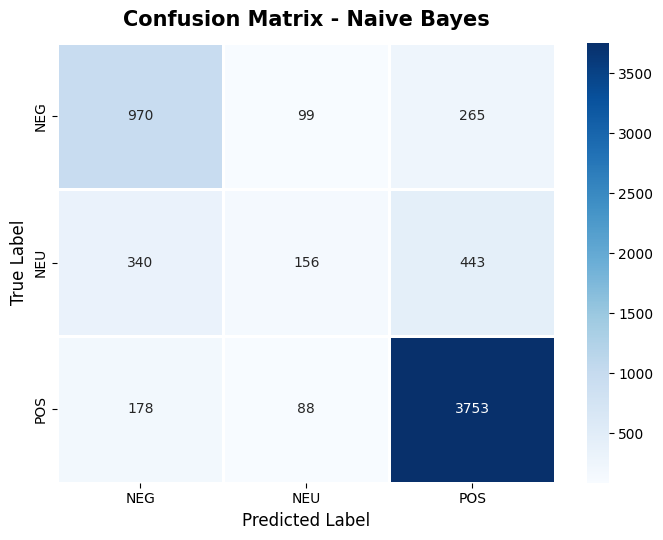

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. PREDICT ON TEST SET

y_pred = best_model.predict(X_test)

# 2. CREATE CONFUSION MATRIX

labels = ["NEG", "NEU", "POS"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

# 3. PLOT CONFUSION MATRIX

plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - Naive Bayes", fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

LOSS & ACCURACY PLOT

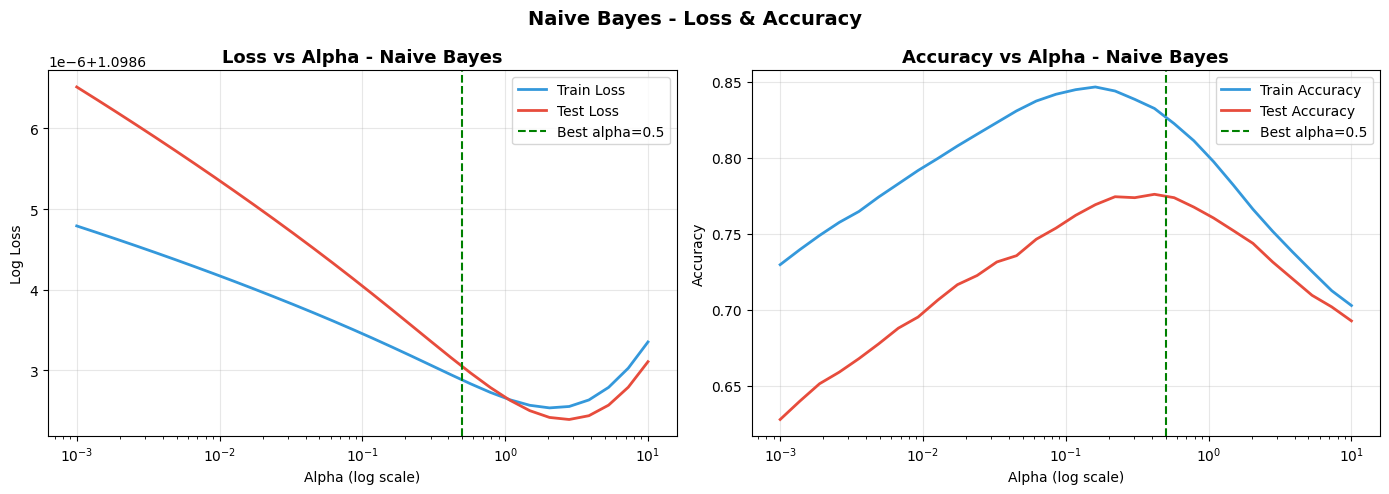

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import log_loss

# Ve bieu do loss va accuracy theo alpha (hyperparameter chinh cua Naive Bayes)
best_features = best_model.named_steps["features"]
X_train_vec   = best_features.transform(X_train)
X_test_vec    = best_features.transform(X_test)

# Dam bao gia tri khong am cho ComplementNB
X_train_vec = X_train_vec.multiply(X_train_vec > 0)
X_test_vec  = X_test_vec.multiply(X_test_vec > 0)

alpha_range     = np.logspace(-3, 1, 30)
train_acc_list  = []
test_acc_list   = []
train_loss_list = []
test_loss_list  = []
classes         = sorted(y_train.unique())

for alpha in alpha_range:
    nb_plot = ComplementNB(alpha=alpha, norm=best_model.named_steps["model"].norm)
    nb_plot.fit(X_train_vec, y_train)

    train_proba = nb_plot.predict_proba(X_train_vec)
    test_proba  = nb_plot.predict_proba(X_test_vec)

    train_acc_list.append(accuracy_score(y_train, nb_plot.predict(X_train_vec)))
    test_acc_list.append(accuracy_score(y_test,   nb_plot.predict(X_test_vec)))
    train_loss_list.append(log_loss(y_train, train_proba, labels=classes))
    test_loss_list.append(log_loss(y_test,   test_proba,  labels=classes))

best_alpha = best_model.named_steps["model"].alpha

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alpha_range, train_loss_list, label="Train Loss", color="#3498db", linewidth=2)
axes[0].semilogx(alpha_range, test_loss_list,  label="Test Loss",  color="#e74c3c", linewidth=2)
axes[0].axvline(best_alpha, color="green", linestyle="--", linewidth=1.5, label=f"Best alpha={best_alpha}")
axes[0].set_title("Loss vs Alpha - Naive Bayes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("Log Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogx(alpha_range, train_acc_list, label="Train Accuracy", color="#3498db", linewidth=2)
axes[1].semilogx(alpha_range, test_acc_list,  label="Test Accuracy",  color="#e74c3c", linewidth=2)
axes[1].axvline(best_alpha, color="green", linestyle="--", linewidth=1.5, label=f"Best alpha={best_alpha}")
axes[1].set_title("Accuracy vs Alpha - Naive Bayes", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Naive Bayes - Loss & Accuracy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
# LƯU KẾT QUẢ CHO STREAMLIT
import json, inspect, shutil, os
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, log_loss

OUTPUT_DIR = "streamlit_assets"
os.makedirs(OUTPUT_DIR, exist_ok=True)
LABELS = ["NEG", "NEU", "POS"]

# 1. Model
joblib.dump(best_model, f"{OUTPUT_DIR}/nb_model.pkl")

# 2. Metrics JSON
report_dict = classification_report(y_test, y_pred, output_dict=True)
metrics = {
    "model_name":    "Naive Bayes (ComplementNB)",
    "best_params":   grid.best_params_,
    "accuracy":      round(main_metric, 4),
    "precision":     round(precision, 4),
    "recall":        round(recall, 4),
    "f1_macro":      round(f1, 4),
    "f1_weighted":   round(f1_score(y_test, y_pred, average="weighted"), 4),
    "params_M":      round(params_million, 4),
    "model_size_mb": round(model_size_mb, 2),
    "fps":           round(fps, 2),
    "inference_ms":  round(inference_time_ms, 4),
    "flops_G":       round(flops_g, 6),
    "per_class": {
        label: {
            "precision": round(report_dict[label]["precision"], 4),
            "recall":    round(report_dict[label]["recall"], 4),
            "f1":        round(report_dict[label]["f1-score"], 4),
            "support":   int(report_dict[label]["support"])
        }
        for label in LABELS if label in report_dict
    }
}
with open(f"{OUTPUT_DIR}/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

# 3. Curve data (alpha range)
curve_data = {
    "alpha_range":  alpha_range.tolist(),
    "train_acc":    train_acc_list,
    "test_acc":     test_acc_list,
    "train_loss":   train_loss_list,
    "test_loss":    test_loss_list,
    "best_alpha":   best_alpha
}
with open(f"{OUTPUT_DIR}/loss_acc_curve.json", "w") as f:
    json.dump(curve_data, f, indent=2)

# 4. Loss & Accuracy curve PNG
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].semilogx(alpha_range, train_loss_list, label="Train Loss", color="#3498db", linewidth=2)
axes[0].semilogx(alpha_range, test_loss_list,  label="Test Loss",  color="#e74c3c", linewidth=2)
axes[0].axvline(best_alpha, color="green", linestyle="--", linewidth=1.5, label=f"Best alpha={best_alpha}")
axes[0].set_title("Loss vs Alpha — Naive Bayes", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Alpha (log scale)"); axes[0].set_ylabel("Log Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].semilogx(alpha_range, train_acc_list, label="Train Accuracy", color="#3498db", linewidth=2)
axes[1].semilogx(alpha_range, test_acc_list,  label="Test Accuracy",  color="#e74c3c", linewidth=2)
axes[1].axvline(best_alpha, color="green", linestyle="--", linewidth=1.5, label=f"Best alpha={best_alpha}")
axes[1].set_title("Accuracy vs Alpha — Naive Bayes", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Alpha (log scale)"); axes[1].set_ylabel("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle("Naive Bayes — Loss & Accuracy", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_acc_curve.png", dpi=150, bbox_inches="tight")
plt.close()

# 5. Confusion matrix số + PNG
cm_save = confusion_matrix(y_test, y_pred, labels=LABELS)
np.save(f"{OUTPUT_DIR}/confusion_matrix.npy", cm_save)
cm_pct  = cm_save.astype(float) / cm_save.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(cm_save, annot=True, fmt="d",    cmap="Blues", ax=axes[0],
            xticklabels=LABELS, yticklabels=LABELS, linewidths=0.8, linecolor="white")
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
sns.heatmap(cm_pct,  annot=True, fmt=".1%",  cmap="Blues", ax=axes[1],
            xticklabels=LABELS, yticklabels=LABELS, linewidths=0.8, linecolor="white")
axes[1].set_title("Confusion Matrix (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
plt.suptitle(f"Naive Bayes — Accuracy: {main_metric:.4f}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.close()

# 6. Preprocess function
preprocess_src = inspect.getsource(preprocess)
with open(f"{OUTPUT_DIR}/preprocess.py", "w", encoding="utf-8") as f:
    f.write("import re\n\n")
    f.write(preprocess_src)

print("=== STREAMLIT ASSETS SAVED ===")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{fname}")
    print(f"  {fname:<35} {size/1024:.1f} KB")


=== STREAMLIT ASSETS SAVED ===
  confusion_matrix.npy                0.2 KB
  confusion_matrix.png                75.2 KB
  loss_acc_curve.json                 3.6 KB
  loss_acc_curve.png                  137.3 KB
  metrics.json                        0.7 KB
  nb_model.pkl                        4251.0 KB
  preprocess.py                       1.0 KB
